Using device: cuda
Model: /kaggle/input/datasets/gwaceee/miccai-dataset/source_domain_model_final.pth
MMD:   /kaggle/input/datasets/gwaceee/miccaidata2/stage2_mmd_results.json

MMD selected 6 layers: [4, 7, 8, 9, 10, 11]

Strategies:
  MMD-Aware (Ours)              : [4, 7, 8, 9, 10, 11]
  Freeze-Early (last 6)         : [6, 7, 8, 9, 10, 11]
  Freeze-Late (first 6)         : [0, 1, 2, 3, 4, 5]
  Random (run 1)                : [0, 1, 3, 4, 10, 11]
  Random (run 2)                : [0, 2, 4, 5, 7, 8]
  Random (run 3)                : [1, 2, 3, 6, 8, 10]

Validation set: 200 | Trainable pool: 2547

STAGE 4: Ablation Study

──────────────────────────────────────────────────  n=10

  [1/12] MMD-Aware (Ours)
    → AUC: 0.9516 | F1: 0.8462 | Acc: 0.8600 | Params: 3,638,786 (4.2%)

  [2/12] Freeze-Early (last 6)
    → AUC: 0.9581 | F1: 0.8842 | Acc: 0.8900 | Params: 3,638,786 (4.2%)

  [3/12] Freeze-Late (first 6)
    → AUC: 0.8496 | F1: 0.5676 | Acc: 0.6800 | Params: 3,638,786 (4.2%)

  [4/1

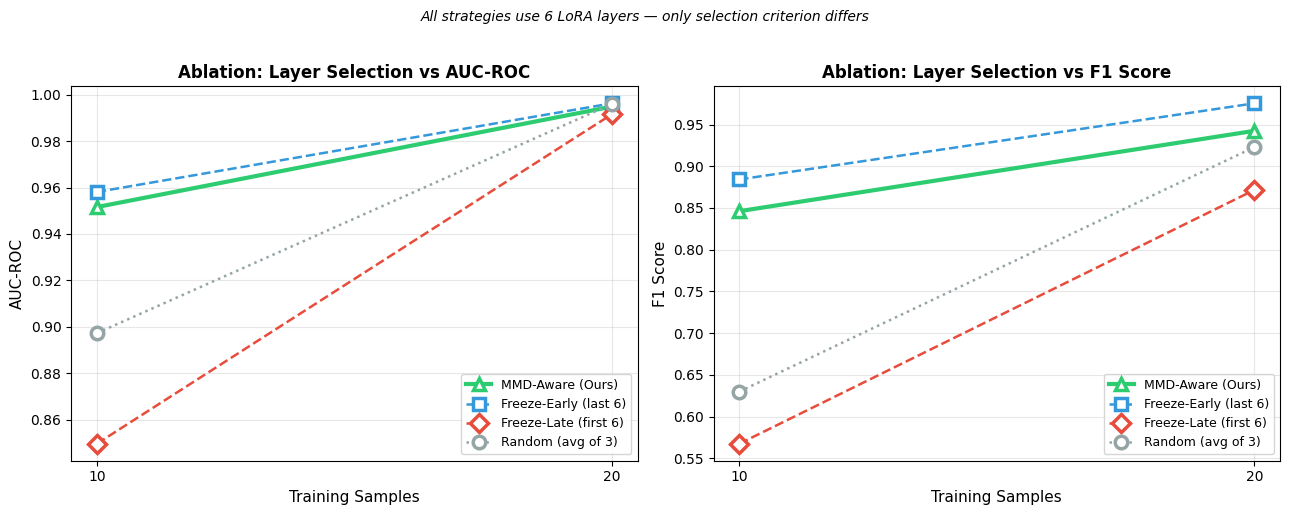

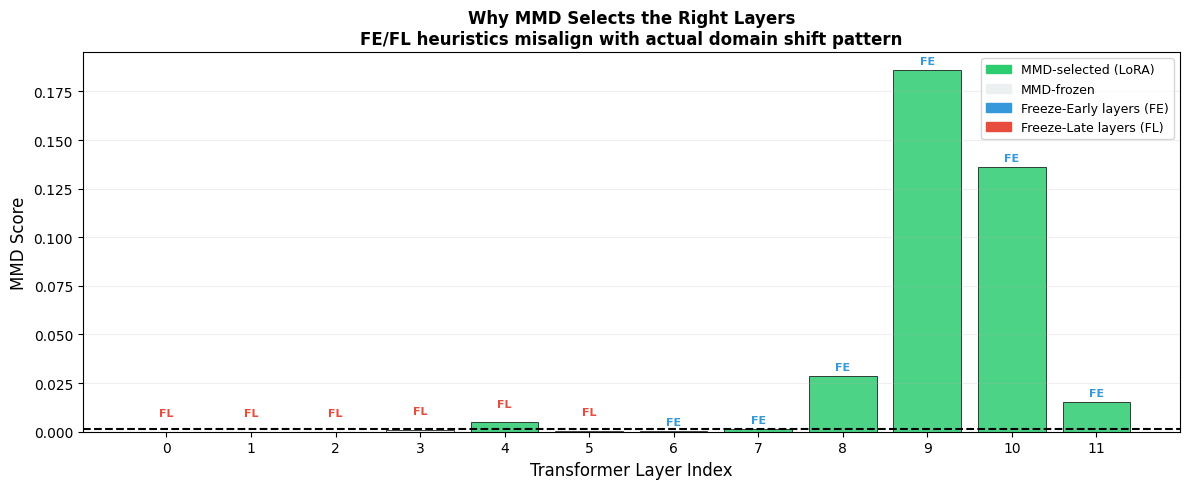


STAGE 4 COMPLETE

n=10: Best → Freeze-Early (last 6) (AUC=0.9581)
  MMD-Aware (Ours)                   : AUC=0.9516 | F1=0.8462 ← OURS
  Freeze-Early (last 6)              : AUC=0.9581 | F1=0.8842
  Freeze-Late (first 6)              : AUC=0.8496 | F1=0.5676
  Random (avg of 3)                  : AUC=0.8973 | F1=0.6300

n=20: Best → Freeze-Early (last 6) (AUC=0.9963)
  MMD-Aware (Ours)                   : AUC=0.9949 | F1=0.9424 ← OURS
  Freeze-Early (last 6)              : AUC=0.9963 | F1=0.9754
  Freeze-Late (first 6)              : AUC=0.9916 | F1=0.8715
  Random (avg of 3)                  : AUC=0.9960 | F1=0.9229

Files saved to /kaggle/working/:
  stage4_ablation_results.csv
  stage4_ablation_figure.png
  stage4_layer_selection_comparison.png

All experiments complete. You are ready to write the paper.


In [1]:
# =============================================================================
# STAGE 4: Ablation Study
# Domain-Shift-Aware LoRA for Malaria Detection in LMIC Settings
#
# Proves that MMD-based layer selection is what matters —
# not just the act of being selective about which layers to adapt.
#
# Compares four layer selection strategies (same LoRA rank throughout):
#   A — MMD-Aware (ours):   layers selected by MMD score
#   B — Freeze-Early:       common heuristic, LoRA on last N layers
#   C — Freeze-Late:        reverse heuristic, LoRA on first N layers
#   D — Random:             random selection of N layers (averaged over 3 runs)
#
# All experiments at n=10 and n=20 only.
# Estimated runtime: ~45-60 minutes on Kaggle T4
# =============================================================================

import os, json, random, copy
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import timm

from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if str(DEVICE) == "cpu":
    raise RuntimeError("Enable GPU: Session options → Accelerator → GPU T4 x2")

# ── PATHS ─────────────────────────────────────────────────────────────────────
import kagglehub
lacuna_path = kagglehub.dataset_download("rajsahu2004/lacuna-malaria-detection-dataset")

STAGE1_MODEL_PATH = None
STAGE2_JSON_PATH  = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full = os.path.join(root, f)
        if f == 'source_domain_model_final.pth': STAGE1_MODEL_PATH = full
        if f == 'stage2_mmd_results.json':       STAGE2_JSON_PATH  = full

if not STAGE1_MODEL_PATH: raise FileNotFoundError("source_domain_model_final.pth not found")
if not STAGE2_JSON_PATH:  raise FileNotFoundError("stage2_mmd_results.json not found")

print(f"Model: {STAGE1_MODEL_PATH}")
print(f"MMD:   {STAGE2_JSON_PATH}")
OUTPUT_DIR = '/kaggle/working/'

# ── LOAD MMD RESULTS ──────────────────────────────────────────────────────────
with open(STAGE2_JSON_PATH) as f:
    mmd_results = json.load(f)

MMD_LORA_LAYERS = mmd_results['lora_layers']
MMD_SCORES      = mmd_results['mmd_scores']
N               = len(MMD_LORA_LAYERS)

print(f"\nMMD selected {N} layers: {MMD_LORA_LAYERS}")

# ── DEFINE STRATEGIES ─────────────────────────────────────────────────────────
freeze_early_layers = list(range(12 - N, 12))
freeze_late_layers  = list(range(0, N))

random.seed(SEED);     r1 = sorted(random.sample(range(12), N))
random.seed(SEED + 1); r2 = sorted(random.sample(range(12), N))
random.seed(SEED + 2); r3 = sorted(random.sample(range(12), N))

STRATEGIES = [
    ('mmd_aware',    'MMD-Aware (Ours)',          MMD_LORA_LAYERS),
    ('freeze_early', f'Freeze-Early (last {N})',  freeze_early_layers),
    ('freeze_late',  f'Freeze-Late (first {N})',  freeze_late_layers),
    ('random_1',     'Random (run 1)',             r1),
    ('random_2',     'Random (run 2)',             r2),
    ('random_3',     'Random (run 3)',             r3),
]

print("\nStrategies:")
for k, name, layers in STRATEGIES:
    print(f"  {name:<30}: {layers}")

# ── TRANSFORMS ────────────────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.2),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])

# ── DATASET ───────────────────────────────────────────────────────────────────
class LacunaDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.transform = transform
        self.img_dir   = Path(img_dir)
        df = pd.read_csv(csv_path)
        il = df.groupby('Image_ID')['class'].apply(
            lambda x: 1 if (x == 'Trophozoite').any() else 0).reset_index()
        il.columns = ['Image_ID', 'label']
        existing = set(os.listdir(self.img_dir))
        il = il[il['Image_ID'].isin(existing)]
        self.samples = list(zip(il['Image_ID'], il['label']))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_id, label = self.samples[idx]
        img = Image.open(self.img_dir / img_id).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

    def balanced_indices(self, n, seed=42):
        random.seed(seed)
        pos = [i for i,(_, l) in enumerate(self.samples) if l==1]
        neg = [i for i,(_, l) in enumerate(self.samples) if l==0]
        n_each = n // 2
        return random.sample(pos, min(n_each,len(pos))) + random.sample(neg, min(n_each,len(neg)))

lacuna_base = LacunaDataset(f"{lacuna_path}/Train.csv",
                            f"{lacuna_path}/images", transform=val_tf)
VAL_IDX       = lacuna_base.balanced_indices(200, seed=999)
TRAINABLE_IDX = list(set(range(len(lacuna_base))) - set(VAL_IDX))

val_loader = DataLoader(Subset(lacuna_base, VAL_IDX),
                        batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f"\nValidation set: {len(VAL_IDX)} | Trainable pool: {len(TRAINABLE_IDX)}")

# ── LORA ──────────────────────────────────────────────────────────────────────
class LoRALinear(nn.Module):
    def __init__(self, layer, rank=4, alpha=8):
        super().__init__()
        self.linear = layer
        self.scale  = alpha / rank
        self.lora_A = nn.Parameter(torch.randn(rank, layer.in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(layer.out_features, rank))
    def forward(self, x):
        return self.linear(x) + (x @ self.lora_A.T @ self.lora_B.T) * self.scale

def apply_lora(model, layers, rank=4, alpha=8):
    for p in model.parameters(): p.requires_grad = False
    for p in model.head.parameters(): p.requires_grad = True
    for i in layers:
        b = model.blocks[i]
        if hasattr(b.attn, 'qkv'): b.attn.qkv = LoRALinear(b.attn.qkv, rank, alpha)
        if hasattr(b.attn, 'proj'):
            for p in b.attn.proj.parameters(): p.requires_grad = True
        for p in b.norm1.parameters(): p.requires_grad = True
        for p in b.norm2.parameters(): p.requires_grad = True
    for p in model.norm.parameters(): p.requires_grad = True
    tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tt = sum(p.numel() for p in model.parameters())
    return model, tr, tt

# ── TRAIN / EVAL ──────────────────────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

def evaluate(model, loader, device):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            probs.extend(torch.softmax(out,1)[:,1].cpu().numpy())
            preds.extend(torch.argmax(out,1).cpu().numpy())
            labels.extend(lbls.cpu().numpy())
    if len(set(labels)) < 2:
        return accuracy_score(labels,preds), f1_score(labels,preds,average='binary',zero_division=0), float('nan')
    return (accuracy_score(labels,preds),
            f1_score(labels,preds,average='binary'),
            roc_auc_score(labels,probs))

# ── RUN ONE EXPERIMENT ────────────────────────────────────────────────────────
def run(strategy_key, target_layers, n_samples, seed=SEED,
        rank=4, alpha=8, epochs=15, lr=1e-4):

    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)
    ckpt  = torch.load(STAGE1_MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    model, tr, tt = apply_lora(model, target_layers, rank, alpha)
    model = model.to(DEVICE)

    # Sample training data
    random.seed(seed)
    train_ds = LacunaDataset(f"{lacuna_path}/Train.csv",
                             f"{lacuna_path}/images", transform=train_tf)
    pool_labels = [train_ds.samples[i][1] for i in TRAINABLE_IDX]
    pos = [TRAINABLE_IDX[i] for i,l in enumerate(pool_labels) if l==1]
    neg = [TRAINABLE_IDX[i] for i,l in enumerate(pool_labels) if l==0]
    n_each = n_samples // 2
    idx = random.sample(pos, min(n_each,len(pos))) + random.sample(neg, min(n_each,len(neg)))

    loader = DataLoader(Subset(train_ds, idx), batch_size=min(16,n_samples),
                        shuffle=True, num_workers=2, pin_memory=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)

    best_auc, best_state = 0.0, None
    for epoch in range(1, epochs+1):
        train_epoch(model, loader, criterion, optimizer, DEVICE)
        _, _, auc = evaluate(model, val_loader, DEVICE)
        scheduler.step()
        if not np.isnan(auc) and auc > best_auc:
            best_auc, best_state = auc, copy.deepcopy(model.state_dict())

    if best_state: model.load_state_dict(best_state)
    acc, f1, auc = evaluate(model, val_loader, DEVICE)
    print(f"    → AUC: {auc:.4f} | F1: {f1:.4f} | Acc: {acc:.4f} | "
          f"Params: {tr:,} ({100*tr/tt:.1f}%)")
    return {'strategy': strategy_key, 'n_samples': n_samples,
            'auc': auc, 'f1': f1, 'accuracy': acc,
            'trainable_params': tr, 'lora_layers': str(target_layers)}

# ── MAIN LOOP ─────────────────────────────────────────────────────────────────
ABLATION_SIZES = [10, 20]
results = []
run_num = 0
total   = len(STRATEGIES) * len(ABLATION_SIZES)

print("\n" + "="*60)
print("STAGE 4: Ablation Study")
print("="*60)

for n in ABLATION_SIZES:
    print(f"\n{'─'*50}  n={n}")
    for key, name, layers in STRATEGIES:
        run_num += 1
        print(f"\n  [{run_num}/{total}] {name}")
        r = run(key, layers, n)
        results.append(r)
        pd.DataFrame(results).to_csv(
            os.path.join(OUTPUT_DIR, 'stage4_ablation_results.csv'), index=False)

# ── AGGREGATE RANDOM RUNS ─────────────────────────────────────────────────────
df = pd.DataFrame(results)
rand_avg = df[df['strategy'].str.startswith('random')].groupby(
    'n_samples')[['auc','f1','accuracy']].mean().reset_index()
rand_avg['strategy'] = 'random_avg'
clean   = pd.concat([df[~df['strategy'].str.startswith('random')], rand_avg],
                    ignore_index=True)

NAMES = {
    'mmd_aware':    'MMD-Aware (Ours)',
    'freeze_early': f'Freeze-Early (last {N})',
    'freeze_late':  f'Freeze-Late (first {N})',
    'random_avg':   'Random (avg of 3)',
}

# ── PRINT RESULTS ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("ABLATION — AUC Scores")
print("="*60)
pivot = clean.pivot(index='n_samples', columns='strategy', values='auc')
pivot = pivot.rename(columns=NAMES)
print(pivot.round(4).to_string())

print("\n" + "="*60)
print("ABLATION — F1 Scores")
print("="*60)
pivot_f1 = clean.pivot(index='n_samples', columns='strategy', values='f1')
pivot_f1 = pivot_f1.rename(columns=NAMES)
print(pivot_f1.round(4).to_string())

# ── FIGURE 3: ABLATION PERFORMANCE ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
COLORS = {'mmd_aware':'#2ecc71','freeze_early':'#3498db',
          'freeze_late':'#e74c3c','random_avg':'#95a5a6'}
STYLES = {'mmd_aware':'^-','freeze_early':'s--',
          'freeze_late':'D--','random_avg':'o:'}

for ax, (mk, ml) in zip(axes, [('auc','AUC-ROC'), ('f1','F1 Score')]):
    for sk in ['mmd_aware','freeze_early','freeze_late','random_avg']:
        sub = clean[clean['strategy']==sk].sort_values('n_samples')
        if sub.empty: continue
        lw = 3.0 if sk == 'mmd_aware' else 1.8
        ax.plot(sub['n_samples'], sub[mk], STYLES[sk], color=COLORS[sk],
                label=NAMES[sk], linewidth=lw, markersize=9,
                markerfacecolor='white', markeredgewidth=2.5)
    ax.set_xlabel('Training Samples', fontsize=11)
    ax.set_ylabel(ml, fontsize=11)
    ax.set_title(f'Ablation: Layer Selection vs {ml}', fontsize=12, fontweight='bold')
    ax.set_xticks(ABLATION_SIZES)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle(f'All strategies use {N} LoRA layers — only selection criterion differs',
             fontsize=10, style='italic', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'stage4_ablation_figure.png'), dpi=200, bbox_inches='tight')
plt.show()

# ── FIGURE 4: LAYER SELECTION vs MMD SCORES ──────────────────────────────────
fig2, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#2ecc71' if i in MMD_LORA_LAYERS else '#ecf0f1' for i in range(12)]
ax.bar(range(12), MMD_SCORES, color=bar_colors, edgecolor='black',
       linewidth=0.6, alpha=0.85)

for i in freeze_early_layers:
    ax.annotate('FE', (i, MMD_SCORES[i]+0.003), ha='center',
                fontsize=8, color='#3498db', fontweight='bold')
for i in freeze_late_layers:
    ax.annotate('FL', (i, MMD_SCORES[i]+0.008), ha='center',
                fontsize=8, color='#e74c3c', fontweight='bold')

ax.axhline(mmd_results['threshold'], color='black', linestyle='--',
           linewidth=1.5, label=f"MMD threshold ({mmd_results['threshold']:.4f})")
ax.set_xlabel('Transformer Layer Index', fontsize=12)
ax.set_ylabel('MMD Score', fontsize=12)
ax.set_title('Why MMD Selects the Right Layers\n'
             'FE/FL heuristics misalign with actual domain shift pattern',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(12))
ax.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='MMD-selected (LoRA)'),
    mpatches.Patch(color='#ecf0f1', label='MMD-frozen'),
    mpatches.Patch(color='#3498db', label='Freeze-Early layers (FE)'),
    mpatches.Patch(color='#e74c3c', label='Freeze-Late layers (FL)'),
], fontsize=9)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'stage4_layer_selection_comparison.png'),
            dpi=200, bbox_inches='tight')
plt.show()

# ── SUMMARY ───────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STAGE 4 COMPLETE")
print("="*60)
for n in ABLATION_SIZES:
    sub = clean[clean['n_samples']==n]
    best = sub.loc[sub['auc'].idxmax()]
    print(f"\nn={n}: Best → {NAMES.get(best['strategy'], best['strategy'])} "
          f"(AUC={best['auc']:.4f})")
    for _, row in sub.iterrows():
        name   = NAMES.get(row['strategy'], row['strategy'])
        marker = ' ← OURS' if row['strategy'] == 'mmd_aware' else ''
        print(f"  {name:<35}: AUC={row['auc']:.4f} | F1={row['f1']:.4f}{marker}")

print(f"\nFiles saved to {OUTPUT_DIR}:")
print(f"  stage4_ablation_results.csv")
print(f"  stage4_ablation_figure.png")
print(f"  stage4_layer_selection_comparison.png")
print(f"\nAll experiments complete. You are ready to write the paper.")